In [1]:
import pandas as pd  #Importing the libraries needed for the tasks
import numpy as np
import matplotlib as plt
%matplotlib inline

df = pd.read_csv('C:\Users\thoma\Desktop\myJupyterNotebooks\loanP_train.csv')  #Loading the source data file

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (127770898.py, line 6)

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
%matplotlib inline

df = pd.read_csv('C:/Users/thoma/Desktop/myJupyterNotebooks/loanP_train.csv')  #I needed to change to forward slashes

In [3]:
data.head()  #Forgot that the data is labeled 'df' in this exercise.

NameError: name 'data' is not defined

In [4]:
df.head()  #Look at first few rows

,Loan_ID,Gender,Marital_Status,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LI0100,Male,Single,0,Yes,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LI0101,Male,Married,1,Yes,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LI0102,Male,Married,0,Yes,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LI0103,Male,Married,0,No,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LI0104,Male,Single,0,Yes,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.describe()  #Look at basic descriptive statistics for the numeric data

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,599.000000,599.000000,578.000000,585.000000,550.00000
mean,5420.687813,1563.913055,145.434256,342.461538,0.84000
std,6169.168633,2456.618360,84.596463,64.868352,0.36694
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,2874.000000,0.000000,100.000000,360.000000,1.00000
50%,3812.000000,1210.000000,126.500000,360.000000,1.00000
75%,5807.500000,2279.000000,165.000000,360.000000,1.00000
max,81000.000000,33837.000000,700.000000,480.000000,1.00000


<Axes: title={'center': 'ApplicantIncome'}, xlabel='Graduate'>

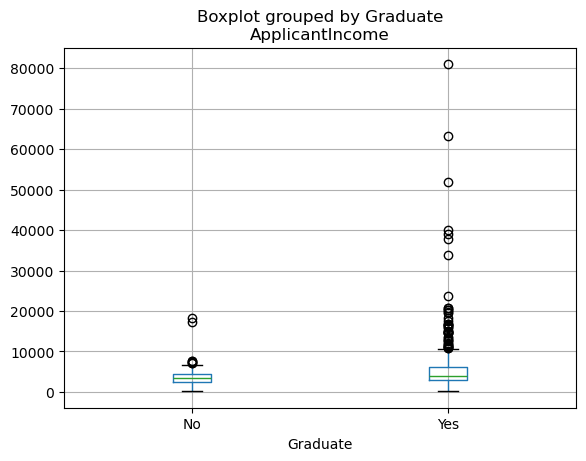

In [6]:
df.boxplot(column='ApplicantIncome', by='Graduate')  # Checking the box plot to see the different distributions of Applicant Income for Graduates vs. Non-graduates

<Axes: >

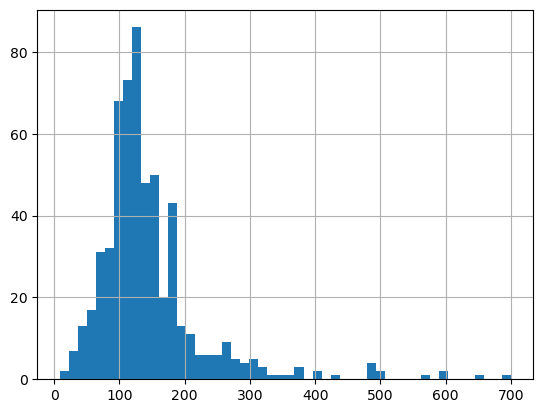

In [7]:
df['LoanAmount'].hist(bins=50) #Create a histogram to see the distribution of loan amounts. There are some outliers.

<Axes: >

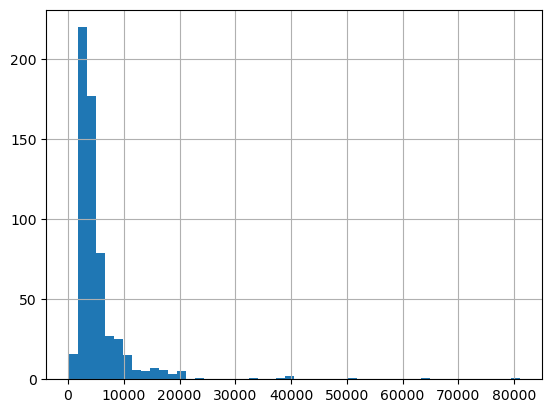

In [8]:
df['ApplicantIncome'].hist(bins=50)  #Create a histogram to see the distribution of ApplicantIncome. There are some outliers.

In [9]:
temp1 = df['Credit_History'].value_counts(ascending=True)  #Hit enter too soon, so code repeats below.

In [10]:
temp1 = df['Credit_History'].value_counts(ascending=True)  #Creates a variable (temp1) and defines it and how to display it
temp2 = df.pivot_table(values='Loan_Status', index=['Credit_History'],aggfunc=lambda x: x.map({'Y':1, 'N':0}).mean()) #Creates a pivot table that summarizes
        #Loan_Status grouped by Credit_History. The aggfunc creates our own custom function where Y=1 and N=0. Finally, .mean computes the mean score to show
        #what percentage of loans were approved for both those with and without Credit_Histories.
print('Frequency Table for Credit History')  #labels the table
print(temp1)  #Prints the temp1 table

print('\nProbability of getting loan for each Credit History class;')  #Labels the table
print(temp2)  #Prints the temp2 table

Frequency Table for Credit History
Credit_History
0.0     88
1.0    462
Name: count, dtype: int64

Probability of getting loan for each Credit History class;
                Loan_Status
Credit_History             
0.0                0.079545
1.0                0.792208


In [11]:
import.matplotlib.pyplot as plt  #Oops...
fig = plt.figure(figsize=(8,4))
ax1 = fig.add_subplot(121)
ax1.set_xlabel('Credit_History')
ax1.set_ylabel('Count of Applicants')
ax1.set_title("Applicants by Credit_History")
temp1.plot(kind='bar')

SyntaxError: invalid syntax (1534960249.py, line 1)

<Axes: title={'center': 'Applicants by Credit_History'}, xlabel='Credit_History', ylabel='Count of Applicants'>

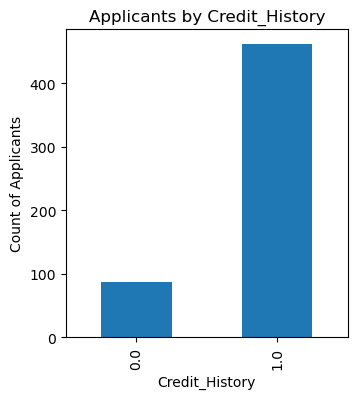

In [12]:
import matplotlib.pyplot as plt  #Imports the plot tool.
fig = plt.figure(figsize=(8,4)) #Creates the 'fig' and defines its size
ax1 = fig.add_subplot(121)  #Creates an area inside fig where a graph can be drawn. 121 defines rows, columns, and plot number.
ax1.set_xlabel('Credit_History')  #Labels the x-axis
ax1.set_ylabel('Count of Applicants') #Labels the y-axis
ax1.set_title("Applicants by Credit_History")  #Labels the overall plot
temp1.plot(kind='bar')  #Defines the plot as a bar chart

In [13]:
df.apply(lambda x: sum(x.isnull()),axis=0)  #Asks for the total number of missing values in each column

Loan_ID               0
Gender               13
Marital_Status        3
Dependents           15
Graduate              0
Self_Employed        30
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
df['LoanAmount'].finllna(df['LoanAmount'].mean(), inplace=True)  #Misspelled so got an error message

AttributeError: 'Series' object has no attribute 'finllna'

In [15]:
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)  #Searches the LoanAmount column for missing values and replaces them with the mean value of the column; inplace=True tells it to apply this to the current data frame.

In [16]:
df.apply(lambda x: sum(x.isnull()), axis=0)  #Again asks for the total number of missing values in each column, and we can see there are now 0 in LoanAmount

Loan_ID               0
Gender               13
Marital_Status        3
Dependents           15
Graduate              0
Self_Employed        30
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [17]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)  #Similar to above, fills the missing values for Loan_Amount_Term and Credit_History with their respective mean values.
df['Credit_History'].fillna(df['Credit_History'].mean(), inplace=True)

C:\Users\thoma\AppData\Local\Temp\ipykernel_23804\2290537505.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)
C:\Users\thoma\AppData\Local\Temp\ipykernel_23804\2290537505.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [18]:
df.mean()  #Although this is exactly what the instructor did, I got the following error.

TypeError: can only concatenate str (not "int") to str

In [19]:
df.dtypes  #Asks for the the data types of all the columns

Loan_ID               object
Gender                object
Marital_Status        object
Dependents            object
Graduate              object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [20]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)  #Keep getting this "FutureWarning." Not sure if it worked or not.

C:\Users\thoma\AppData\Local\Temp\ipykernel_23804\1585969625.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)


In [21]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_True'].mean(), inplace=True)  #Trying again

KeyError: 'Loan_Amount_True'

In [22]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)  #Trying again

C:\Users\thoma\AppData\Local\Temp\ipykernel_23804\1585969625.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)


In [23]:
df.mean()  #Trying this again. Even though it's the same as the instructor's code, I get an error message

TypeError: can only concatenate str (not "int") to str

In [24]:
df.mean(numeric_only=True)  #Googling around, I found this suggestion to add 'numeric_only=True' which worked to get the means of the numeric columns.

ApplicantIncome      5420.687813
CoapplicantIncome    1563.913055
LoanAmount            145.434256
Loan_Amount_Term      342.461538
Credit_History          0.840000
dtype: float64

In [25]:
from sklearn.linear_model import LogisticRegression  #This block of code imports the tools from Scikit learn module
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import metrics

In [26]:
X = df.iloc[:, [8,10]].values  #Extracts the independent variables credit history and loan amount using their column numbers (8 & 10)
y = df.iloc[:, 12].values  #Extracts the dependent variable loan status using its column number (12)

In [27]:
from sklearn.model_selection import train_test_split  #Importing the tool to split the dataset into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)  #Passes the X and y variables we set in code block 26 into the train_test_split tool and sets the size of the test_size sample at 25% of the dataset

In [28]:
from sklearn.preprocessing import StandardScaler  #Imports the StandardScaler tool
sc_X = StandardScaler()  #Abbreviates the name of the tool for ease of use
X_train = sc_X.fit_transform(X_train)  #Since we had some extreme outliers in the data, we use this tool to normalize the data for both X_train and X_test
X_test = sc_X.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression  #Imports the LogisticRegression tool
classifier = LogisticRegression(random_state = 0)  #Makes the analysis start from the same baseline and repeat the same every time
classifier.fit(X_train, y_train)  #.fit() tells it learn the relationship between the designated variables (X_train and y_train). This is 'training' the model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = classifier.predict(X_test)  #Creates a variable (y_pred) and defines it as the predicted Test set results
y_pred  #Displays the predicted results

array(['Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N',
       'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y'], dtype=object)

In [31]:
from sklearn.metrics import confusion_matrix  #Imports the confusion_matrix method
cm = confusion_matrix(y_test, y_pred)  #Builds a confusion matrix to compare y_test data to the y_pred variable to compare the model's predicted values to actual values.
cm  #Displays the results

array([[ 18,  27],
       [  2, 103]])

In [32]:
from sklearn.metrics import accuracy_score  #Imports the accuracy_score method
accuracy_score(y_test, y_pred)  #Compares the y_test and y_pred data to produce an accuracy score of approximately 81%. The model predicts correctly 81% of the time. This is done by comparing
            #False positives and True positives to overall number of positives and False negatives and True negatives to overall number of negatives.

0.8066666666666666

In [33]:
left = pd.DataFrame({'key': ['foo', 'bar'], 'lval': [1, 2]})  #These last blocks of code seemed designed to just teach us how to create and merge data frames.
left  #It assigns values of 1 to foo and 2 to bar.

,key,lval
0,foo,1
1,bar,2


In [34]:
right = pd.DataFrame({'key': ['foo', 'bar'], 'lval': [1,2]})  #Mistakenly entered the lval again instead of the correct rval
right

,key,lval
0,foo,1
1,bar,2


In [35]:
left = pd.DataFrame({'key': ['foo', 'bar'], 'lval': [1, 2]})  #Re-entering the lval values
left

,key,lval
0,foo,1
1,bar,2


In [36]:
right = pd.DataFrame({'key': ['foo', 'bar', 'bar'], 'rval': [3, 4, 5]})  #Entering the correct rval values
right

,key,rval
0,foo,3
1,bar,4
2,bar,5


In [37]:
pd.merge(left,right, on='key')  #Merging the lvals and rvals into one table.

,key,lval,rval
0,foo,1,3
1,bar,2,4
2,bar,2,5


In [38]:
one = pd.DataFrame(np.random.randn(5, 4))  #Creates a data frame with 5 rows and 4 columns and assigns random values

In [39]:
one

,0,1,2,3
0,1.169985,0.711526,1.269103,0.429899
1,2.042156,-0.113019,0.832984,-0.143321
2,-0.511463,1.698416,-1.768013,-0.664176
3,-0.881997,0.114223,-0.279281,-2.033901
4,1.546763,-1.108553,-0.280512,0.342414


In [40]:
twp = pd.DataFrame(np.random.randn(5,4))  #Typo so I got an error message
two

NameError: name 'two' is not defined

In [41]:
two = pd.DataFrame(np.random.randn(5,4)) #Creates a data frame with 5 rows and 4 columns and assigns random values
two

,0,1,2,3
0,-0.103859,-0.583774,0.504034,-0.579848
1,-0.960831,2.564799,0.231349,-1.212591
2,-0.131660,0.285147,-0.470935,1.499159
3,-0.626670,1.834119,-0.255423,-0.277152
4,2.082085,-1.529196,0.111727,-0.573692


In [43]:
pd.merge(one, two)  #Just seeing what would happen...

,0,1,2,3
